In [65]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

In [4]:
import nltk

In [3]:
# 말뭉치를 다운로드
# c:/nltk_data or d:/nltk_data or 
# c:/Users/내컴퓨터이름/anconda3/nltk_data
# c:/Users/내컴퓨터이름/anconda3/lib/nltk_data
# c:/Users/내컴퓨터이름/anaconda3/share/nltk_data
# c:/Users/내컴퓨터이름/anaconda3/share/nltk_data
# C:\Users\Admin\AppData\Roaming\nltk_data
nltk.download()

showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml
showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml
showing info https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/index.xml


True

In [5]:
nltk.corpus.gutenberg.fileids()

['austen-emma.txt',
 'austen-persuasion.txt',
 'austen-sense.txt',
 'bible-kjv.txt',
 'blake-poems.txt',
 'bryant-stories.txt',
 'burgess-busterbrown.txt',
 'carroll-alice.txt',
 'chesterton-ball.txt',
 'chesterton-brown.txt',
 'chesterton-thursday.txt',
 'edgeworth-parents.txt',
 'melville-moby_dick.txt',
 'milton-paradise.txt',
 'shakespeare-caesar.txt',
 'shakespeare-hamlet.txt',
 'shakespeare-macbeth.txt',
 'whitman-leaves.txt']

In [6]:
emma = nltk.corpus.gutenberg.raw('austen-emma.txt')
print(emma[:10])
print('글자수 :', len(emma))

[Emma by J
글자수 : 887071


In [7]:
from nltk.tokenize import sent_tokenize  # sentence
sent_tokens = sent_tokenize(emma)
print(sent_tokens[0])
print('문장수 : ', len(sent_tokens))
print("%r" %sent_tokens[0])  # 이스케이프 문자 등을 입력 그대로 가져옴

[Emma by Jane Austen 1816]

VOLUME I

CHAPTER I


Emma Woodhouse, handsome, clever, and rich, with a comfortable home
and happy disposition, seemed to unite some of the best blessings
of existence; and had lived nearly twenty-one years in the world
with very little to distress or vex her.
문장수 :  7456
'[Emma by Jane Austen 1816]\n\nVOLUME I\n\nCHAPTER I\n\n\nEmma Woodhouse, handsome, clever, and rich, with a comfortable home\nand happy disposition, seemed to unite some of the best blessings\nof existence; and had lived nearly twenty-one years in the world\nwith very little to distress or vex her.'


In [8]:
# word_tokenize() : 단어토큰으로 쪼갠 list 반환
from nltk.tokenize import word_tokenize
print(word_tokenize(sent_tokens[0]))

['[', 'Emma', 'by', 'Jane', 'Austen', '1816', ']', 'VOLUME', 'I', 'CHAPTER', 'I', 'Emma', 'Woodhouse', ',', 'handsome', ',', 'clever', ',', 'and', 'rich', ',', 'with', 'a', 'comfortable', 'home', 'and', 'happy', 'disposition', ',', 'seemed', 'to', 'unite', 'some', 'of', 'the', 'best', 'blessings', 'of', 'existence', ';', 'and', 'had', 'lived', 'nearly', 'twenty-one', 'years', 'in', 'the', 'world', 'with', 'very', 'little', 'to', 'distress', 'or', 'vex', 'her', '.']


In [9]:
# RegexpTokenizer() : 토큰화할 때 해당 정규표현식에 해당하는 word만 적용
from nltk.tokenize import RegexpTokenizer
digitRet= RegexpTokenizer('\d+')  # 숫자 정규식 토크나이저
alphaRet= RegexpTokenizer('\w+')  # 문자+숫자 정규식 토크나이저
digits = digitRet.tokenize(sent_tokens[0])
words = alphaRet.tokenize(sent_tokens[0])
print('digits :', digits)
print('words :', words) 

digits : ['1816']
words : ['Emma', 'by', 'Jane', 'Austen', '1816', 'VOLUME', 'I', 'CHAPTER', 'I', 'Emma', 'Woodhouse', 'handsome', 'clever', 'and', 'rich', 'with', 'a', 'comfortable', 'home', 'and', 'happy', 'disposition', 'seemed', 'to', 'unite', 'some', 'of', 'the', 'best', 'blessings', 'of', 'existence', 'and', 'had', 'lived', 'nearly', 'twenty', 'one', 'years', 'in', 'the', 'world', 'with', 'very', 'little', 'to', 'distress', 'or', 'vex', 'her']


In [11]:
# 형태소 분석 - 어간추출 1
words2 = ['sending', 'cooking', 'files', 'lives', 'crying', 'dying']
from nltk.stem import PorterStemmer
pst = PorterStemmer() # 객체생성
pst.stem(words2[0])  # str 함수를 사용하므로, 리스트를 해제해야함

'send'

In [21]:
[pst.stem(word) for word in words2]

['send', 'cook', 'file', 'live', 'cri', 'die']

In [12]:
# 어간 추출(2)
from nltk.stem import LancasterStemmer
lst = LancasterStemmer()
[lst.stem(word) for word in words2]

['send', 'cook', 'fil', 'liv', 'cry', 'dying']

In [13]:
# 어간 추출(3)
from nltk.stem import RegexpStemmer
rst = RegexpStemmer('ing')
[rst.stem(word) for word in words2]

['send', 'cook', 'files', 'lives', 'cry', 'dy']

# 퀴즈 : emma소설안에서
- 특수문자가 들어가지 않는 3글자 이상의 단어만 추출해서 품사태킹을 하시오. ex)[('emma','명'), ('was','동'),...]
- "Emma" 단어가 몇번 등장하며, 품사 태깅이 어떤 품사들로 되어 있는지 모두 출력하시오
- 내가 원하는 품사(명사)의 단어만 뽑아 등장하는 명사의 종류 갯수를 출력하시오

In [17]:
from nltk.tag import pos_tag

In [20]:
reg = RegexpTokenizer('[a-zA-Z0-9가-힣]{3,}')
reg_token_emma = reg.tokenize(emma)
emma_tag = pos_tag(reg_token_emma)
print('3글자 이상의 단어 출현수 :', len(emma_tag))
print('3글자 이상의 단어 종류수 :', len(set(emma_tag)))

emma_tag[:3]

3글자 이상의 단어 출현수 : 123817
3글자 이상의 단어 종류수 : 11434


[('Emma', 'NNP'), ('Jane', 'NNP'), ('Austen', 'NNP')]

In [29]:
count = 0
tag_list = []
for token, tag in emma_tag:
    # print(token, tag)
    
    if token =='Emma':
        count += 1
        tag_list.append(tag)
print(f'Emma 등장 횟수 : {count}, 품사 :{len(set(tag_list))}개 - {set(tag_list)}')

Emma 등장 횟수 : 865, 품사 :10개 - {'RB', 'NNP', 'NN', 'NNS', 'VBD', 'JJ', 'VB', 'VBN', 'VBP', 'NNPS'}


In [33]:
'tag==NNP 의 개수 : ' + str(len(set( [word for word, tag in emma_tag if tag =='NNP'] )))

'tag==NNP 의 개수 : 565'

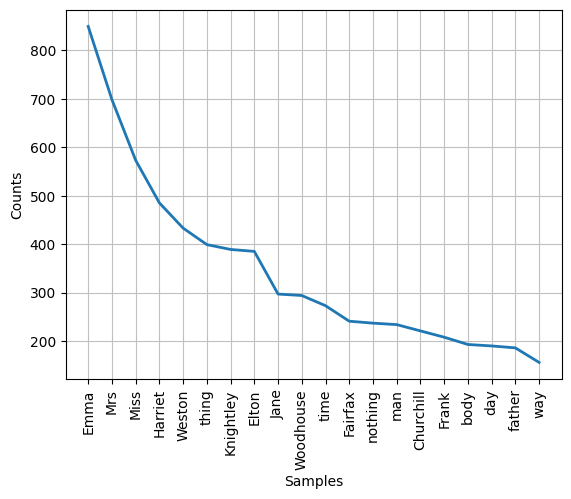

In [35]:
import matplotlib.pyplot as plt
from nltk import Text
noun_list = [word for word, tag in emma_tag if tag in ('NNP', 'NNS', 'NN', 'NNPS')]
emma_text = Text(noun_list)
emma_text.plot(20)
plt.show()

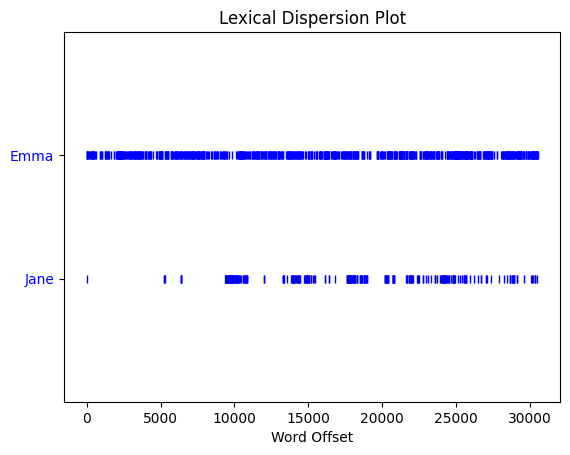

In [36]:
emma_text.dispersion_plot(['Emma','Jane'])

In [51]:
from nltk import FreqDist
freq_noun = FreqDist(noun_list)
dic = dict(freq_noun)

In [55]:
import pandas as pd
wordcnt = pd.Series(dic)
wordcnt.sort_values(ascending=False, inplace=True)

In [58]:
wordcnt[wordcnt>400].index

Index(['Emma', 'Mrs', 'Miss', 'Harriet', 'Weston'], dtype='object')

# ①naver open API를 활용하여 네이버지식인 "전주여행"과 "경주여행"을 각각 500건씩 검색(re ? )후 백업 -> ②품사태깅 백업 -> ③명사만 추출 -> ④빈도분석(DataFrame) 후 백업-> ⑤빈도 시각화(워드클라우드, Text) ->⑥ Word2Vec

# 1. 네이버 open API를 활용하여 검색 추출
- 검색어, no, title, link, description, title + ' ' + description(total_text)

In [67]:
import requests
import os
import sys
import json
import re
import pandas as pd
from html import unescape
from dotenv import load_dotenv

In [60]:
os.getcwd()

'D:\\AI-X\\source\\07_자연어처리'

In [62]:
%ls .env

 D 드라이브의 볼륨: 새 볼륨
 볼륨 일련 번호: CAAC-7D8A

 D:\AI-X\source\07_자연어처리 디렉터리

2025-06-21  오후 10:42                65 .env
               1개 파일                  65 바이트
               0개 디렉터리  396,316,798,976 바이트 남음


In [68]:
load_dotenv()

True

In [121]:
import os
import sys
import urllib.request
client_id = os.getenv('naver_id')
client_secret = os.getenv('naver_key')
url = "https://openapi.naver.com/v1/datalab/search";
body = "{\"startDate\":\"2016-01-01\",\"endDate\":\"2025-05-31\",\"timeUnit\":\"month\",\
\"keywordGroups\":[\
{\"groupName\":\"쌀\",\"keywords\":[\"쌀\",\"쌀 10kg\",\"신동진쌀\",\"고시히카리\",\"햅쌀\",\"유기농 쌀\",\"쌀 가격\",\"찹쌀\",\"현미\",\"백미\"]},\
{\"groupName\":\"사과\",\"keywords\":[\"사과\",\"부사 사과\",\"홍로 사과\",\"사과 가격\",\"유기농 사과\",\"사과즙\",\"햇사과\",\"청송 사과\",\"사과 효능\",\"사과 선물세트\"]},\
{\"groupName\":\"배추\",\"keywords\":[\"배추\",\"알배기 배추\",\"배추 가격\",\"배추김치\",\"절임배추\",\"유기농 배추\",\"김장 배추\",\"배추 작황\",\"배추 농사\",\"햇배추\"]},\
{\"groupName\":\"상추\",\"keywords\":[\"상추\",\"적상추\",\"청상추\",\"유기농 상추\",\"상추 가격\",\"상추 샐러드\",\"상추 키우기\",\"상추 효능\",\"상추 농사\",\"상추 재배\"]},\
{\"groupName\":\"양파\",\"keywords\":[\"양파\",\"햇양파\",\"유기농 양파\",\"양파즙\",\"양파 가격\",\"양파 보관법\",\"양파 재배\",\"양파 효능\",\"양파 농사\",\"적양파\"]}]}";

request = urllib.request.Request(url)
request.add_header("X-Naver-Client-Id",client_id)
request.add_header("X-Naver-Client-Secret",client_secret)
request.add_header("Content-Type","application/json")
response = urllib.request.urlopen(request, data=body.encode("utf-8"))
rescode = response.getcode()
if(rescode==200):
    response_body = response.read()
    print(response_body.decode('utf-8'))
else:
    print("Error Code:" + rescode)

{"startDate":"2016-01-01","endDate":"2025-05-31","timeUnit":"month","results":[{"title":"쌀","keywords":["쌀","쌀 10kg","신동진쌀","고시히카리","햅쌀","유기농 쌀","쌀 가격","찹쌀","현미","백미"],"data":[{"period":"2016-01-01","ratio":4.94979},{"period":"2016-02-01","ratio":4.67022},{"period":"2016-03-01","ratio":5.29776},{"period":"2016-04-01","ratio":4.88676},{"period":"2016-05-01","ratio":6.46096},{"period":"2016-06-01","ratio":5.4904},{"period":"2016-07-01","ratio":4.97208},{"period":"2016-08-01","ratio":4.71461},{"period":"2016-09-01","ratio":9.90189},{"period":"2016-10-01","ratio":6.5353},{"period":"2016-11-01","ratio":5.44544},{"period":"2016-12-01","ratio":7.43314},{"period":"2017-01-01","ratio":5.34896},{"period":"2017-02-01","ratio":4.48127},{"period":"2017-03-01","ratio":5.42927},{"period":"2017-04-01","ratio":4.7199},{"period":"2017-05-01","ratio":4.95994},{"period":"2017-06-01","ratio":5.23001},{"period":"2017-07-01","ratio":4.8148},{"period":"2017-08-01","ratio":10.94909},{"period":"2017-09-01","rat

In [122]:
data = json.loads(response_body.decode('utf-8'))
data_list = []
for el in data['results']:
#    print(el.items())
     for data in el['data']:
        print(el['title'], el['keywords'], data['period'], data['ratio'])
        data_list.append({'title' : el['title'],
                         'keywords' : ', '.join(el['keywords']),
                         'period' : data['period'],
                         'ratio' :data['ratio']})
df_food = pd.DataFrame(data_list)
df_food.to_csv('data/naver_datalab_농작물_trend_201601-202505.csv', encoding='cp949')

쌀 ['쌀', '쌀 10kg', '신동진쌀', '고시히카리', '햅쌀', '유기농 쌀', '쌀 가격', '찹쌀', '현미', '백미'] 2016-01-01 4.94979
쌀 ['쌀', '쌀 10kg', '신동진쌀', '고시히카리', '햅쌀', '유기농 쌀', '쌀 가격', '찹쌀', '현미', '백미'] 2016-02-01 4.67022
쌀 ['쌀', '쌀 10kg', '신동진쌀', '고시히카리', '햅쌀', '유기농 쌀', '쌀 가격', '찹쌀', '현미', '백미'] 2016-03-01 5.29776
쌀 ['쌀', '쌀 10kg', '신동진쌀', '고시히카리', '햅쌀', '유기농 쌀', '쌀 가격', '찹쌀', '현미', '백미'] 2016-04-01 4.88676
쌀 ['쌀', '쌀 10kg', '신동진쌀', '고시히카리', '햅쌀', '유기농 쌀', '쌀 가격', '찹쌀', '현미', '백미'] 2016-05-01 6.46096
쌀 ['쌀', '쌀 10kg', '신동진쌀', '고시히카리', '햅쌀', '유기농 쌀', '쌀 가격', '찹쌀', '현미', '백미'] 2016-06-01 5.4904
쌀 ['쌀', '쌀 10kg', '신동진쌀', '고시히카리', '햅쌀', '유기농 쌀', '쌀 가격', '찹쌀', '현미', '백미'] 2016-07-01 4.97208
쌀 ['쌀', '쌀 10kg', '신동진쌀', '고시히카리', '햅쌀', '유기농 쌀', '쌀 가격', '찹쌀', '현미', '백미'] 2016-08-01 4.71461
쌀 ['쌀', '쌀 10kg', '신동진쌀', '고시히카리', '햅쌀', '유기농 쌀', '쌀 가격', '찹쌀', '현미', '백미'] 2016-09-01 9.90189
쌀 ['쌀', '쌀 10kg', '신동진쌀', '고시히카리', '햅쌀', '유기농 쌀', '쌀 가격', '찹쌀', '현미', '백미'] 2016-10-01 6.5353
쌀 ['쌀', '쌀 10kg', '신동진쌀', '고시히카리', '햅쌀', '유기농 쌀', '쌀

,title,keywords,period,ratio
0,쌀,"쌀, 쌀 10kg, 신동진쌀, 고시히카리, 햅쌀, 유기농 쌀, 쌀 가격, 찹쌀, 현...",2016-01-01,4.94979
1,쌀,"쌀, 쌀 10kg, 신동진쌀, 고시히카리, 햅쌀, 유기농 쌀, 쌀 가격, 찹쌀, 현...",2016-02-01,4.67022
2,쌀,"쌀, 쌀 10kg, 신동진쌀, 고시히카리, 햅쌀, 유기농 쌀, 쌀 가격, 찹쌀, 현...",2016-03-01,5.29776
3,쌀,"쌀, 쌀 10kg, 신동진쌀, 고시히카리, 햅쌀, 유기농 쌀, 쌀 가격, 찹쌀, 현...",2016-04-01,4.88676
4,쌀,"쌀, 쌀 10kg, 신동진쌀, 고시히카리, 햅쌀, 유기농 쌀, 쌀 가격, 찹쌀, 현...",2016-05-01,6.46096
...,...,...,...,...
560,양파,"양파, 햇양파, 유기농 양파, 양파즙, 양파 가격, 양파 보관법, 양파 재배, 양파...",2025-01-01,3.22665
561,양파,"양파, 햇양파, 유기농 양파, 양파즙, 양파 가격, 양파 보관법, 양파 재배, 양파...",2025-02-01,3.17108
562,양파,"양파, 햇양파, 유기농 양파, 양파즙, 양파 가격, 양파 보관법, 양파 재배, 양파...",2025-03-01,4.01228
563,양파,"양파, 햇양파, 유기농 양파, 양파즙, 양파 가격, 양파 보관법, 양파 재배, 양파...",2025-04-01,4.54905


In [123]:
df.to_csv('data/naver_datalab_농작물_trend_201601-202505.csv', encoding='cp949')

In [117]:
client_id = os.getenv('naver_id')
client_secret = os.getenv('naver_key')
url = "https://openapi.naver.com/v1/datalab/search";
body = "{\"startDate\":\"2016-01-01\",\"endDate\":\"2025-05-31\",\"timeUnit\":\"month\",\
\"keywordGroups\":[\
{\"groupName\":\"가뭄\",\"keywords\":[\"가뭄\",\"가뭄 피해\",\"농작물 가뭄\",\"가뭄 작황\",\"강수량 부족\",\"논밭 가뭄\",\"가뭄 농업\",\"가뭄 대비\",\"물 부족\",\"가뭄 영향\"]},\
{\"groupName\":\"태풍\",\"keywords\":[\"태풍\",\"태풍 피해\",\"태풍 강도\",\"태풍 피해 농가\",\"태풍 농작물\",\"태풍 수확\",\"태풍 침수\",\"태풍 경로\",\"태풍 피해 복구\",\"태풍 경보\"]},\
{\"groupName\":\"한파\",\"keywords\":[\"한파\",\"한파 피해\",\"한파 주의보\",\"한파 경보\",\"한파 농작물\",\"한파 작황\",\"한파 피해 복구\",\"겨울 한파\",\"강추위\",\"작물 동해\"]},\
{\"groupName\":\"폭염\",\"keywords\":[\"폭염\",\"폭염 피해\",\"폭염 경보\",\"폭염 주의보\",\"폭염 작황\",\"폭염 농작물\",\"폭염 스트레스\",\"고온 피해\",\"농작물 고온\",\"폭염 재해\"]},\
{\"groupName\":\"병충해\",\"keywords\":[\"병충해\",\"농작물 병충해\",\"해충 피해\",\"작물 병충해\",\"농약 방제\",\"농작물 해충\",\"병충해 예방법\",\"병충해 발생\",\"병충해 방제\",\"농사 병충해\"]}\
]}";

request = urllib.request.Request(url)
request.add_header("X-Naver-Client-Id",client_id)
request.add_header("X-Naver-Client-Secret",client_secret)
request.add_header("Content-Type","application/json")
response = urllib.request.urlopen(request, data=body.encode("utf-8"))
rescode = response.getcode()
if(rescode==200):
    response_body = response.read()
    print(response_body.decode('utf-8'))
else:
    print("Error Code:" + rescode)

{"startDate":"2016-01-01","endDate":"2025-05-31","timeUnit":"month","results":[{"title":"가뭄","keywords":["가뭄","가뭄 피해","농작물 가뭄","가뭄 작황","강수량 부족","논밭 가뭄","가뭄 농업","가뭄 대비","물 부족","가뭄 영향"],"data":[{"period":"2016-01-01","ratio":0.03046},{"period":"2016-02-01","ratio":0.02536},{"period":"2016-03-01","ratio":0.03862},{"period":"2016-04-01","ratio":0.04678},{"period":"2016-05-01","ratio":0.06055},{"period":"2016-06-01","ratio":0.05812},{"period":"2016-07-01","ratio":0.05227},{"period":"2016-08-01","ratio":0.07631},{"period":"2016-09-01","ratio":0.04073},{"period":"2016-10-01","ratio":0.03254},{"period":"2016-11-01","ratio":0.03092},{"period":"2016-12-01","ratio":0.02138},{"period":"2017-01-01","ratio":0.01635},{"period":"2017-02-01","ratio":0.02122},{"period":"2017-03-01","ratio":0.02957},{"period":"2017-04-01","ratio":0.0363},{"period":"2017-05-01","ratio":0.16072},{"period":"2017-06-01","ratio":1.43121},{"period":"2017-07-01","ratio":0.54709},{"period":"2017-08-01","ratio":0.0721},{"period":

In [118]:
data = json.loads(response_body.decode('utf-8'))
data_list = []
for el in data['results']:
#    print(el.items())
     for data in el['data']:
        print(el['title'], el['keywords'], data['period'], data['ratio'])
        data_list.append({'title' : el['title'],
                         'keywords' : ', '.join(el['keywords']),
                         'period' : data['period'],
                         'ratio' :data['ratio']})
df = pd.DataFrame(data_list)
df

가뭄 ['가뭄', '가뭄 피해', '농작물 가뭄', '가뭄 작황', '강수량 부족', '논밭 가뭄', '가뭄 농업', '가뭄 대비', '물 부족', '가뭄 영향'] 2016-01-01 0.03046
가뭄 ['가뭄', '가뭄 피해', '농작물 가뭄', '가뭄 작황', '강수량 부족', '논밭 가뭄', '가뭄 농업', '가뭄 대비', '물 부족', '가뭄 영향'] 2016-02-01 0.02536
가뭄 ['가뭄', '가뭄 피해', '농작물 가뭄', '가뭄 작황', '강수량 부족', '논밭 가뭄', '가뭄 농업', '가뭄 대비', '물 부족', '가뭄 영향'] 2016-03-01 0.03862
가뭄 ['가뭄', '가뭄 피해', '농작물 가뭄', '가뭄 작황', '강수량 부족', '논밭 가뭄', '가뭄 농업', '가뭄 대비', '물 부족', '가뭄 영향'] 2016-04-01 0.04678
가뭄 ['가뭄', '가뭄 피해', '농작물 가뭄', '가뭄 작황', '강수량 부족', '논밭 가뭄', '가뭄 농업', '가뭄 대비', '물 부족', '가뭄 영향'] 2016-05-01 0.06055
가뭄 ['가뭄', '가뭄 피해', '농작물 가뭄', '가뭄 작황', '강수량 부족', '논밭 가뭄', '가뭄 농업', '가뭄 대비', '물 부족', '가뭄 영향'] 2016-06-01 0.05812
가뭄 ['가뭄', '가뭄 피해', '농작물 가뭄', '가뭄 작황', '강수량 부족', '논밭 가뭄', '가뭄 농업', '가뭄 대비', '물 부족', '가뭄 영향'] 2016-07-01 0.05227
가뭄 ['가뭄', '가뭄 피해', '농작물 가뭄', '가뭄 작황', '강수량 부족', '논밭 가뭄', '가뭄 농업', '가뭄 대비', '물 부족', '가뭄 영향'] 2016-08-01 0.07631
가뭄 ['가뭄', '가뭄 피해', '농작물 가뭄', '가뭄 작황', '강수량 부족', '논밭 가뭄', '가뭄 농업', '가뭄 대비', '물 부족', '가뭄 영향'] 2016-09-01 0.04073
가

,title,keywords,period,ratio
0,가뭄,"가뭄, 가뭄 피해, 농작물 가뭄, 가뭄 작황, 강수량 부족, 논밭 가뭄, 가뭄 농업...",2016-01-01,0.03046
1,가뭄,"가뭄, 가뭄 피해, 농작물 가뭄, 가뭄 작황, 강수량 부족, 논밭 가뭄, 가뭄 농업...",2016-02-01,0.02536
2,가뭄,"가뭄, 가뭄 피해, 농작물 가뭄, 가뭄 작황, 강수량 부족, 논밭 가뭄, 가뭄 농업...",2016-03-01,0.03862
3,가뭄,"가뭄, 가뭄 피해, 농작물 가뭄, 가뭄 작황, 강수량 부족, 논밭 가뭄, 가뭄 농업...",2016-04-01,0.04678
4,가뭄,"가뭄, 가뭄 피해, 농작물 가뭄, 가뭄 작황, 강수량 부족, 논밭 가뭄, 가뭄 농업...",2016-05-01,0.06055
...,...,...,...,...
560,병충해,"병충해, 농작물 병충해, 해충 피해, 작물 병충해, 농약 방제, 농작물 해충, 병충...",2025-01-01,0.00263
561,병충해,"병충해, 농작물 병충해, 해충 피해, 작물 병충해, 농약 방제, 농작물 해충, 병충...",2025-02-01,0.00255
562,병충해,"병충해, 농작물 병충해, 해충 피해, 작물 병충해, 농약 방제, 농작물 해충, 병충...",2025-03-01,0.00359
563,병충해,"병충해, 농작물 병충해, 해충 피해, 작물 병충해, 농약 방제, 농작물 해충, 병충...",2025-04-01,0.00432


In [120]:
df.to_csv('data/naver_datalab_재해키워드_trend_201601-202505.csv', encoding='cp949')